In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/crowdedness-at-the-campus-gym/data.csv


In [2]:
import seaborn as sns 
import matplotlib.pyplot as plt

df = pd.read_csv('/kaggle/input/crowdedness-at-the-campus-gym/data.csv')
df.head()

,number_people,date,timestamp,day_of_week,is_weekend,is_holiday,temperature,is_start_of_semester,is_during_semester,month,hour
0,37,2015-08-14 17:00:11-07:00,61211,4,0,0,71.76,0,0,8,17
1,45,2015-08-14 17:20:14-07:00,62414,4,0,0,71.76,0,0,8,17
2,40,2015-08-14 17:30:15-07:00,63015,4,0,0,71.76,0,0,8,17
3,44,2015-08-14 17:40:16-07:00,63616,4,0,0,71.76,0,0,8,17
4,45,2015-08-14 17:50:17-07:00,64217,4,0,0,71.76,0,0,8,17


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62184 entries, 0 to 62183
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   number_people         62184 non-null  int64  
 1   date                  62184 non-null  object 
 2   timestamp             62184 non-null  int64  
 3   day_of_week           62184 non-null  int64  
 4   is_weekend            62184 non-null  int64  
 5   is_holiday            62184 non-null  int64  
 6   temperature           62184 non-null  float64
 7   is_start_of_semester  62184 non-null  int64  
 8   is_during_semester    62184 non-null  int64  
 9   month                 62184 non-null  int64  
 10  hour                  62184 non-null  int64  
dtypes: float64(1), int64(9), object(1)
memory usage: 5.2+ MB


In [4]:
df.describe() # I want add year column

,number_people,timestamp,day_of_week,is_weekend,is_holiday,temperature,is_start_of_semester,is_during_semester,month,hour
count,62184.000000,62184.000000,62184.000000,62184.000000,62184.000000,62184.000000,62184.000000,62184.000000,62184.000000,62184.000000
mean,29.072543,45799.437958,2.982504,0.282870,0.002573,58.557108,0.078831,0.660218,7.439824,12.236460
std,22.689026,24211.275891,1.996825,0.450398,0.050660,6.316396,0.269476,0.473639,3.445069,6.717631
min,0.000000,0.000000,0.000000,0.000000,0.000000,38.140000,0.000000,0.000000,1.000000,0.000000
25%,9.000000,26624.000000,1.000000,0.000000,0.000000,55.000000,0.000000,0.000000,5.000000,7.000000
50%,28.000000,46522.500000,3.000000,0.000000,0.000000,58.340000,0.000000,1.000000,8.000000,12.000000
75%,43.000000,66612.000000,5.000000,1.000000,0.000000,62.280000,0.000000,1.000000,10.000000,18.000000
max,145.000000,86399.000000,6.000000,1.000000,1.000000,87.170000,1.000000,1.000000,12.000000,23.000000


In [5]:
df['date'] = pd.to_datetime(df['date'] , utc = True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62184 entries, 0 to 62183
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype              
---  ------                --------------  -----              
 0   number_people         62184 non-null  int64              
 1   date                  62184 non-null  datetime64[ns, UTC]
 2   timestamp             62184 non-null  int64              
 3   day_of_week           62184 non-null  int64              
 4   is_weekend            62184 non-null  int64              
 5   is_holiday            62184 non-null  int64              
 6   temperature           62184 non-null  float64            
 7   is_start_of_semester  62184 non-null  int64              
 8   is_during_semester    62184 non-null  int64              
 9   month                 62184 non-null  int64              
 10  hour                  62184 non-null  int64              
dtypes: datetime64[ns, UTC](1), float64(1), int64(9)
memory usage: 5.2 M

In [6]:
df['year'] = df['date'].dt.year
df.drop(columns = 'date' , axis = 1 , inplace = True)
df.head()
# Ready for EDA

,number_people,timestamp,day_of_week,is_weekend,is_holiday,temperature,is_start_of_semester,is_during_semester,month,hour,year
0,37,61211,4,0,0,71.76,0,0,8,17,2015
1,45,62414,4,0,0,71.76,0,0,8,17,2015
2,40,63015,4,0,0,71.76,0,0,8,17,2015
3,44,63616,4,0,0,71.76,0,0,8,17,2015
4,45,64217,4,0,0,71.76,0,0,8,17,2015


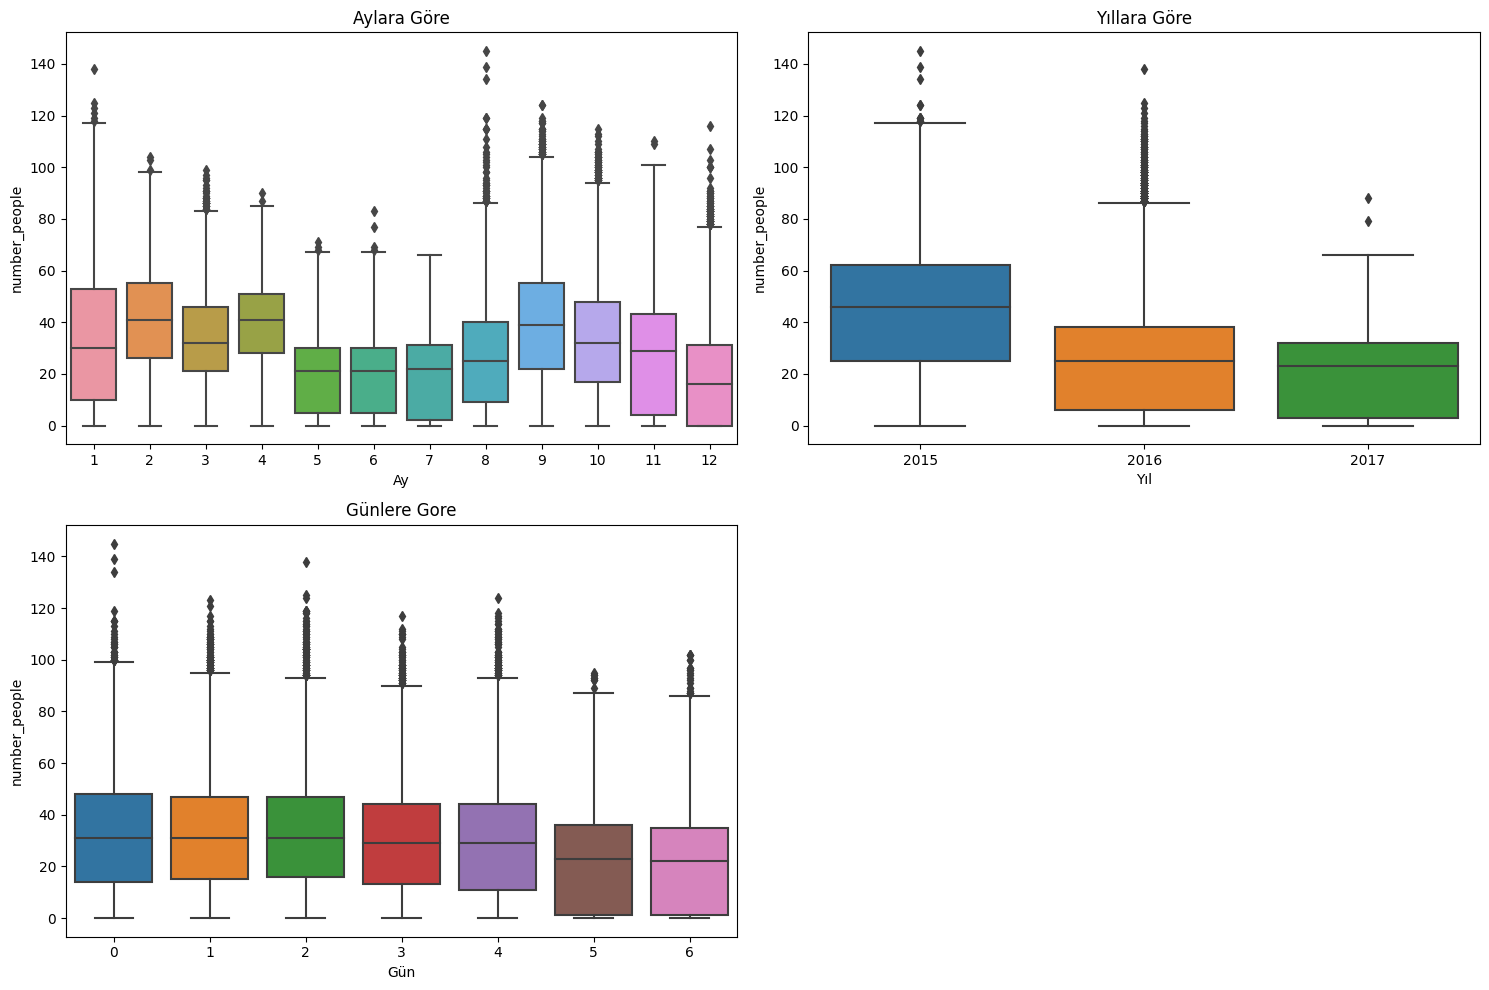

In [7]:

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

sns.boxplot(data=df, x='month', y='number_people', ax=axes[0 , 0])
axes[0 , 0].set_title('Aylara Göre')
axes[0 , 0].set_xlabel('Ay')


sns.boxplot(data=df, x='year', y='number_people', ax=axes[0 , 1])
axes[0 , 1].set_title('Yıllara Göre')
axes[0,  1].set_xlabel('Yıl')

sns.boxplot(data = df , x = 'day_of_week' , y = 'number_people' , ax = axes[1 , 0])
axes[1, 0].set_title('Günlere Gore')
axes[1 ,0].set_xlabel('Gün')

fig.delaxes(axes[1 , 1])
            
plt.tight_layout()
plt.show()

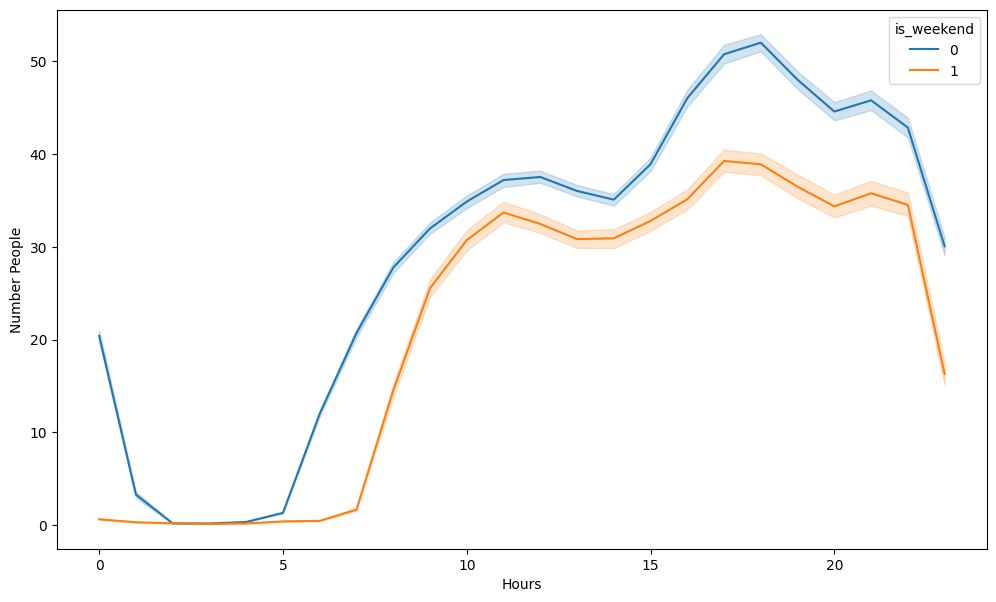

In [8]:
import warnings
warnings.filterwarnings('ignore')
plt.figure(figsize = (12 , 7))
sns.lineplot(data = df , x = 'hour' , y = 'number_people' , hue = 'is_weekend' , markers = True )
plt.xlabel('Hours')
plt.ylabel('Number People')
plt.show()

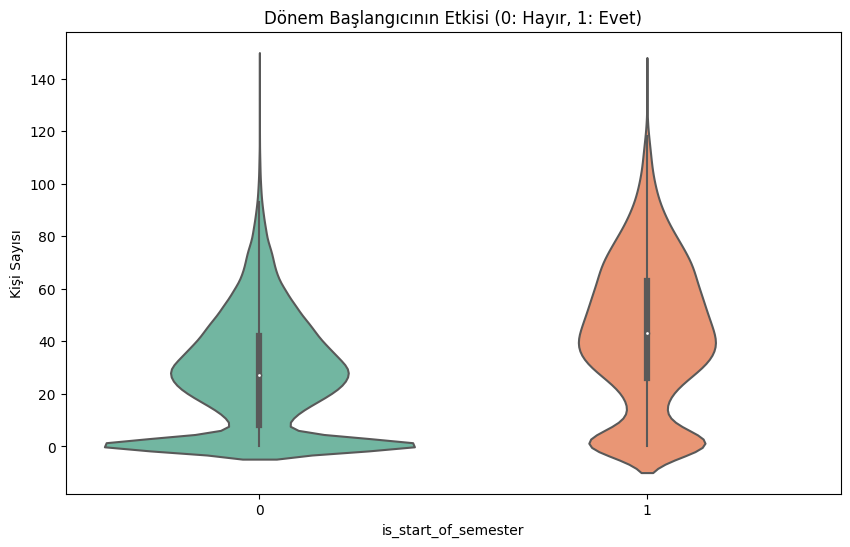

In [9]:
plt.figure(figsize=(10, 6))
sns.violinplot(data=df, x='is_start_of_semester', y='number_people', palette="Set2")

plt.title('Dönem Başlangıcının Etkisi (0: Hayır, 1: Evet)')
plt.ylabel('Kişi Sayısı')
plt.show()

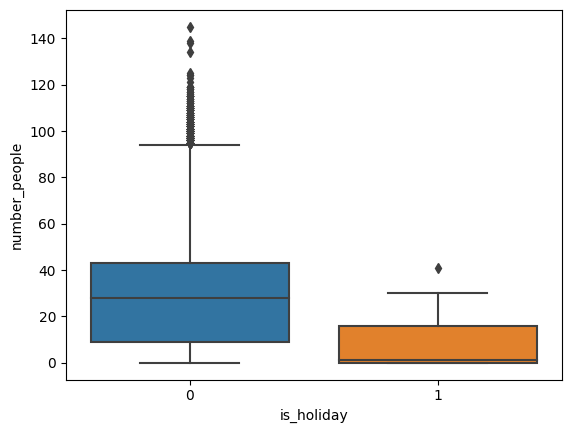

In [10]:
sns.boxplot(data = df , x = 'is_holiday' , y = 'number_people')
plt.show()

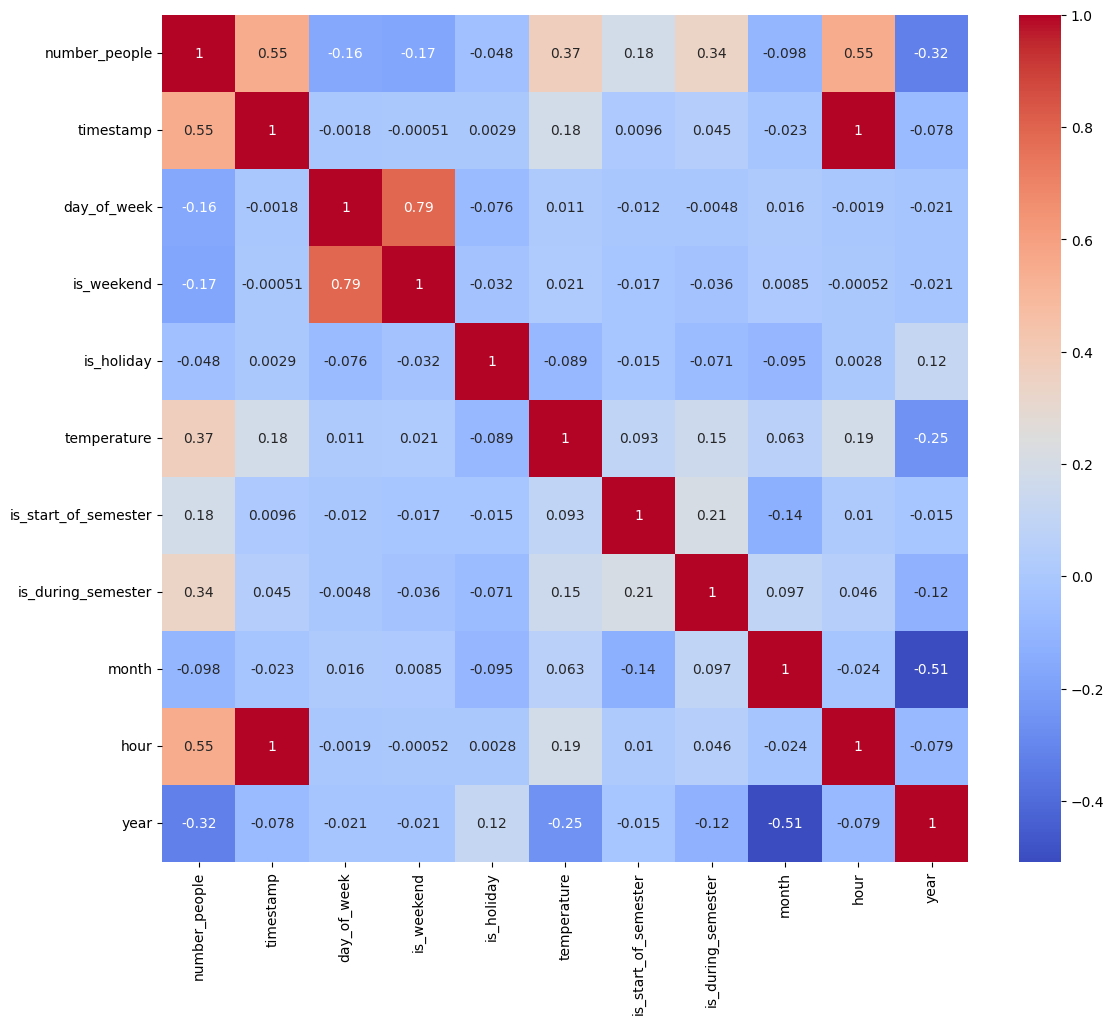

In [11]:
plt.figure(figsize = (13 , 11))
sns.heatmap(df.corr(), annot = True , cmap = 'coolwarm')
plt.show()

In [12]:
df.drop(columns = 'timestamp' , axis = 1 , inplace = True)
df.head()

,number_people,day_of_week,is_weekend,is_holiday,temperature,is_start_of_semester,is_during_semester,month,hour,year
0,37,4,0,0,71.76,0,0,8,17,2015
1,45,4,0,0,71.76,0,0,8,17,2015
2,40,4,0,0,71.76,0,0,8,17,2015
3,44,4,0,0,71.76,0,0,8,17,2015
4,45,4,0,0,71.76,0,0,8,17,2015


In [13]:
from sklearn.model_selection import train_test_split
X = df.drop(columns = 'number_people' , axis= 1 )
y = df['number_people']

X_train , X_test , y_train , y_test = train_test_split(X , y , test_size = 0.3 , random_state = 15)

from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [14]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression , Lasso , Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor

In [15]:
from sklearn.metrics import mean_absolute_error , mean_squared_error , r2_score
def calculate_metric (true , pred) : 
    mae = mean_absolute_error(true , pred)
    mse = mean_squared_error(true , pred)
    r2 = r2_score(true , pred)
    rmse = np.sqrt(mean_squared_error(true , pred))
    return mae , mse , r2 , rmse


In [16]:
models = {
    'Linear Regression' : LinearRegression(),
    'Ridge' : Ridge(),
    'Lasso' : Lasso(),
    'K-Neighbors Regressor' : KNeighborsRegressor(),
    'Decision Tree' : DecisionTreeRegressor(),
    'Random Forest Regressor' : RandomForestRegressor(),
}

In [17]:
for i in range (len(list(models))) : 
    model = list(models.values())[i]
    model.fit(X_train , y_train)

    y_train_predict = model.predict(X_train) 
    y_test_predict =model.predict(X_test)

    train_mae , train_mse , train_r2 , train_rmse = calculate_metric(y_train , y_train_predict)
    test_mae , test_mse , test_r2 , test_rmse = calculate_metric(y_test , y_test_predict)

    print(list(models.values())[i])
    print('Evaluation For Train Set')
    print('R2  : ' , train_r2)
    print('MAE : ' , train_mae)
    print('MSE : ' , train_mse)

    print('\n--------------------------------------------')

    print('Evaluation For Test Set')
    print('R2  : ' , test_r2)
    print('MAE : ' , test_mae)
    print('MSE : ' , test_mse)
    print('\n\n')

LinearRegression()
Evaluation For Train Set
R2  :  0.5990450245502594
MAE :  10.736278545598697
MSE :  205.15013531793014

--------------------------------------------
Evaluation For Test Set
R2  :  0.6011719749263943
MAE :  10.772974414744668
MSE :  208.1786957813254



Ridge()
Evaluation For Train Set
R2  :  0.5990450147440858
MAE :  10.736295699374098
MSE :  205.15014033529613

--------------------------------------------
Evaluation For Test Set
R2  :  0.6011715218520708
MAE :  10.772983004208292
MSE :  208.17893227529223



Lasso()
Evaluation For Train Set
R2  :  0.5508762820757948
MAE :  11.50841601310547
MSE :  229.79585526602852

--------------------------------------------
Evaluation For Test Set
R2  :  0.5520472927829585
MAE :  11.517099938801106
MSE :  233.82060561804062



KNeighborsRegressor()
Evaluation For Train Set
R2  :  0.939119061619818
MAE :  3.7366752435214114
MSE :  31.149963242051097

--------------------------------------------
Evaluation For Test Set
R2  :  0.89

In [18]:
# HyperParameter Tuning

knn_params = {
    'n_neighbors' : [2,3,4,5,8,10,15]    
}
rf_params = {
    'n_estimators' : [10 , 50 , 100 , 500 , 1000], 
    'max_depth' : [5 , 10 , 15 , None],
    'max_features' : [2, 5 , 8 , 10 , None]
}

randomcvmodels = [('KNN' , KNeighborsRegressor() , knn_params),
                  ('RF' , RandomForestRegressor() , rf_params)]

In [19]:
from sklearn.model_selection import RandomizedSearchCV
for name , model , params in randomcvmodels :
    random = RandomizedSearchCV(estimator = model , param_distributions = params , cv = 5 , n_jobs = -1)
    random.fit(X_train, y_train)
    print('Best Params : ' , name , random.best_params_)

Best Params :  KNN {'n_neighbors': 2}
Best Params :  RF {'n_estimators': 10, 'max_features': 5, 'max_depth': None}


In [20]:
models = {
    'K-Neighbors Regressor' : KNeighborsRegressor(n_neighbors = 2),
    'Random Forest Regressor' : RandomForestRegressor(n_estimators = 1000 , max_features = 10 , max_depth = None)
}
for i in range (len(list(models))) : 
    model = list(models.values())[i]
    model.fit(X_train , y_train)

    y_train_predict = model.predict(X_train) 
    y_test_predict =model.predict(X_test)

    train_mae , train_mse , train_r2 , train_rmse = calculate_metric(y_train , y_train_predict)
    test_mae , test_mse , test_r2 , test_rmse = calculate_metric(y_test , y_test_predict)

    print(list(models.values())[i])
    print('Evaluation For Train Set')
    print('R2  : ' , train_r2)
    print('MAE : ' , train_mae)
    print('MSE : ' , train_mse)

    print('\n--------------------------------------------')

    print('Evaluation For Test Set')
    print('R2  : ' , test_r2)
    print('MAE : ' , test_mae)
    print('MSE : ' , test_mse)
    print('\n\n')


KNeighborsRegressor(n_neighbors=2)
Evaluation For Train Set
R2  :  0.9431069511376866
MAE :  3.500218250321632
MSE :  29.10954443117074

--------------------------------------------
Evaluation For Test Set
R2  :  0.9075880274979791
MAE :  4.672330617495712
MSE :  48.23684069468268



RandomForestRegressor(max_features=10, n_estimators=1000)
Evaluation For Train Set
R2  :  0.9576109631130032
MAE :  3.1587716361204814
MSE :  21.688511643009118

--------------------------------------------
Evaluation For Test Set
R2  :  0.9197376940617616
MAE :  4.327905099928513
MSE :  41.89500516554841



